In [1]:
# import packages
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-trial noise
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xarray as xr

In [2]:
MODEL_PATH   = 'test_best_temp_model.pt'

In [3]:
ds= xr.open_dataset('data/02_2025_Berlin_temp.nc')
print(ds)

# Extract variables
temp_c = ds['t2m'] - 273.15  # Kelvin to Celsius
lat    = ds['latitude']
lon    = ds['longitude']
time   = ds['valid_time']

# Quick check
print(temp_c.shape)
print(time.values[0], time.values[-1])

<xarray.Dataset> Size: 121MB
Dimensions:     (valid_time: 672, latitude: 421, longitude: 107)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5kB 2025-02-01 ... 2025-02-28T23:...
    expver      (valid_time) <U4 11kB ...
  * latitude    (latitude) float64 3kB 52.5 52.25 52.0 ... -52.0 -52.25 -52.5
  * longitude   (longitude) float64 856B -13.25 -13.0 -12.75 ... 13.0 13.25
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 121MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-24T10:26 GRIB to CDM+CF via cfgrib-0.9.1...
(672, 421, 107)
2025-02-01T00:00:00.000000000 2025-02-28T23:00:00.000000000


In [4]:
# Select nearest point to Berlin
berlin_lat = 52.52
berlin_lon = 13.41

temp_berlin = temp_c.sel(
    latitude=berlin_lat,
    longitude=berlin_lon,
    method='nearest'
)

print(temp_berlin.shape)  # should be (24,)
temp_1d = temp_berlin.values  # numpy array
print(temp_1d)

(672,)
[ 3.11416626e+00  2.28506470e+00  1.74331665e+00  1.30728149e+00
  1.43496704e+00  1.54898071e+00  1.70523071e+00  1.71182251e+00
  2.02334595e+00  2.80532837e+00  3.25576782e+00  3.69033813e+00
  4.17886353e+00  4.65518188e+00  4.81387329e+00  4.45596313e+00
  2.58389282e+00  2.12246704e+00  2.55166626e+00  2.72842407e+00
  2.69912720e+00  2.62734985e+00  2.50479126e+00  2.19668579e+00
  1.86367798e+00  1.53799438e+00  1.28848267e+00  8.39752197e-01
  4.28375244e-01  1.87164307e-01 -9.15527344e-05  3.20709229e-01
  5.15289307e-01  1.41397095e+00  2.33364868e+00  3.29141235e+00
  4.05825806e+00  4.41983032e+00  4.48037720e+00  4.25747681e+00
  2.41128540e+00  4.40338135e-01 -3.70697021e-01 -9.84954834e-01
 -9.93743896e-01 -1.13558960e+00  1.02935791e-01  1.05133057e-01
 -1.98822021e-01 -6.71234131e-01 -1.09188843e+00 -2.29550171e+00
 -3.03988647e+00 -3.39266968e+00 -3.00204468e+00 -3.29476929e+00
 -1.73617554e+00  7.21099854e-01  2.27700806e+00  3.60195923e+00
  4.41641235e+00  

In [9]:
LAG          = 20    # shorter = faster windowing + smaller tensors
HORIZON      = 1     # 1-step ahead captures ENSO peaks sharply
N_TRIALS     = 10    # Optuna trials (was 20)
OPTUNA_EPOCHS = 25   # max epochs per trial (was 80)
FINAL_EPOCHS  = 80   # final training budget
BATCH         = 128  # larger batch = faster GPU/CPU steps
SEED          = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [10]:
X_raw      = temp_1d.reshape(-1, 1)  # (24, 1)
y_raw      = temp_1d                 # (24,)
N_FEATURES = 1
N          = len(temp_1d)

train_end = int(0.70 * N)
test_end  = int(0.90 * N)

print(f"N={N}, train={train_end}, test={test_end-train_end}, val={N-test_end}")

N=672, train=470, test=134, val=68


In [11]:
# ── 2. SLIDING WINDOW ─────────────────────────────────────────────────────────
def make_windows(X, y, lag=LAG, horizon=HORIZON):
    Xw, yw = [], []
    for i in range(lag, len(X) - horizon):
        Xw.append(X[i - lag:i])        # (lag, F) — keeps time order
        yw.append(y[i + horizon])
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)

def make_windows_X(X, lag=LAG):
    return np.array([X[i - lag:i] for i in range(lag, len(X))], dtype=np.float32)

X_train_w, y_train = make_windows(X_raw[:train_end],         y_raw[:train_end])
X_test_w,  y_test  = make_windows(X_raw[train_end:test_end], y_raw[train_end:test_end])
X_val_w,   y_val   = make_windows(X_raw[test_end:],          y_raw[test_end:])
print(f"train {X_train_w.shape} | test {X_test_w.shape} | val {X_val_w.shape}")

# ── 3. SCALE ──────────────────────────────────────────────────────────────────
def fit_scale(Xw):
    sc = StandardScaler()
    sc.fit(Xw.reshape(-1, Xw.shape[2]))
    return sc

def transform(Xw, sc):
    s = Xw.shape
    return sc.transform(Xw.reshape(-1, s[2])).reshape(s).astype(np.float32)

scaler      = fit_scale(X_train_w)
X_tr_sc     = transform(X_train_w, scaler)
X_te_sc     = transform(X_test_w,  scaler)
X_va_sc     = transform(X_val_w,   scaler)

y_mean, y_std  = y_train.mean(), y_train.std()
y_tr_n = (y_train - y_mean) / y_std
y_te_n = (y_test  - y_mean) / y_std
y_va_n = (y_val   - y_mean) / y_std

# ── 4. DATASET ────────────────────────────────────────────────────────────────
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def loader(X, y, shuffle): return DataLoader(SeqDS(X, y), batch_size=BATCH, shuffle=shuffle)

# ── 5. MODELS ─────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, n_feat, hidden=64, n_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):                        # x: (B, lag, F)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class CNNLSTMModel(nn.Module):
    def __init__(self, n_feat, channels=32, hidden=64, n_layers=1, dropout=0.2):
        super().__init__()
        self.cnn  = nn.Sequential(
            nn.Conv1d(n_feat, channels, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.lstm = nn.LSTM(channels, hidden, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):                        # x: (B, lag, F)
        x = self.cnn(x.permute(0, 2, 1))        # → (B, channels, lag)
        x = x.permute(0, 2, 1)                  # → (B, lag, channels)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

# ── 6. TRAIN HELPER ───────────────────────────────────────────────────────────
def run_training(model, X_tr, y_tr, X_v, y_v,
                 lr, max_epochs, patience, trial=None):
    tr_loader = loader(X_tr, y_tr, shuffle=True)
    va_loader = loader(X_v,  y_v,  shuffle=False)
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    best_val, no_improve = float('inf'), 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in tr_loader:
            opt.zero_grad()
            F.mse_loss(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            vals = [F.mse_loss(model(xb), yb).item() for xb, yb in va_loader]
        avg = float(np.mean(vals))
        sched.step(avg)

        if avg < best_val:
            best_val, no_improve = avg, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

        if trial:
            trial.report(avg, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return best_val

# ── 7. OPTUNA (small, fast) ───────────────────────────────────────────────────
def objective(trial):
    arch    = trial.suggest_categorical('arch',    ['lstm', 'cnn_lstm'])
    hidden  = trial.suggest_categorical('hidden',  [32, 64, 128])
    lr      = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3)

    if arch == 'lstm':
        model = LSTMModel(N_FEATURES, hidden=hidden, dropout=dropout)
    else:
        ch    = trial.suggest_categorical('channels', [16, 32])
        model = CNNLSTMModel(N_FEATURES, channels=ch, hidden=hidden, dropout=dropout)

    return run_training(model, X_tr_sc, y_tr_n, X_va_sc, y_va_n,
                        lr=lr, max_epochs=OPTUNA_EPOCHS, patience=5, trial=trial)

print(f"Optuna search — {N_TRIALS} trials × {OPTUNA_EPOCHS} epochs max …")
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
)
study.optimize(objective, n_trials=N_TRIALS)
bp = study.best_params
print("Best params:", bp)
print("Best val MSE:", f"{study.best_value:.6f}")

# ── 8. FINAL MODEL ────────────────────────────────────────────────────────────
if bp['arch'] == 'lstm':
    model = LSTMModel(N_FEATURES, hidden=bp['hidden'], dropout=bp['dropout'])
else:
    model = CNNLSTMModel(N_FEATURES, channels=bp.get('channels', 32),
                         hidden=bp['hidden'], dropout=bp['dropout'])

tr_loader = loader(X_tr_sc, y_tr_n, shuffle=True)
va_loader = loader(X_va_sc, y_va_n, shuffle=False)
opt   = torch.optim.Adam(model.parameters(), lr=bp['lr'])
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=6, factor=0.5)

train_losses, val_losses = [], []
best_val, no_improve     = float('inf'), 0
best_state               = copy.deepcopy(model.state_dict())

print(f"\nFinal training — up to {FINAL_EPOCHS} epochs …")
for epoch in range(FINAL_EPOCHS):
    model.train()
    tl = []
    for xb, yb in tr_loader:
        opt.zero_grad()
        loss = F.mse_loss(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl.append(loss.item())
    train_losses.append(np.mean(tl))

    model.eval()
    with torch.no_grad():
        vl = [F.mse_loss(model(xb), yb).item() for xb, yb in va_loader]
    avg_val = float(np.mean(vl))
    val_losses.append(avg_val)
    sched.step(avg_val)
    print(f"  Epoch {epoch+1:03d} | train {train_losses[-1]:.5f} | val {avg_val:.5f}")

    if avg_val < best_val:
        best_val, no_improve = avg_val, 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        no_improve += 1
        if no_improve >= 12:
            print(f"  Early stop at epoch {epoch+1}")
            break

model.load_state_dict(best_state)


train (449, 20, 1) | test (113, 20, 1) | val (47, 20, 1)
Optuna search — 10 trials × 25 epochs max …
Best params: {'arch': 'cnn_lstm', 'hidden': 128, 'lr': 0.002915630483576832, 'dropout': 0.26942852299558573, 'channels': 16}
Best val MSE: 0.076386

Final training — up to 80 epochs …
  Epoch 001 | train 0.87816 | val 1.64719
  Epoch 002 | train 0.61462 | val 0.27111
  Epoch 003 | train 0.46452 | val 1.10761
  Epoch 004 | train 0.38760 | val 1.01224
  Epoch 005 | train 0.26244 | val 0.39887
  Epoch 006 | train 0.20908 | val 0.32302
  Epoch 007 | train 0.15168 | val 0.48466
  Epoch 008 | train 0.13795 | val 0.23086
  Epoch 009 | train 0.12422 | val 0.19207
  Epoch 010 | train 0.11118 | val 0.34888
  Epoch 011 | train 0.10060 | val 0.22365
  Epoch 012 | train 0.09333 | val 0.17216
  Epoch 013 | train 0.09394 | val 0.21497
  Epoch 014 | train 0.11194 | val 0.10074
  Epoch 015 | train 0.09104 | val 0.31745
  Epoch 016 | train 0.08885 | val 0.11407
  Epoch 017 | train 0.08615 | val 0.09394
 

<All keys matched successfully>

Test  RMSE : 2.2704
Val   RMSE : 1.0346
Test  R²   : 0.6262


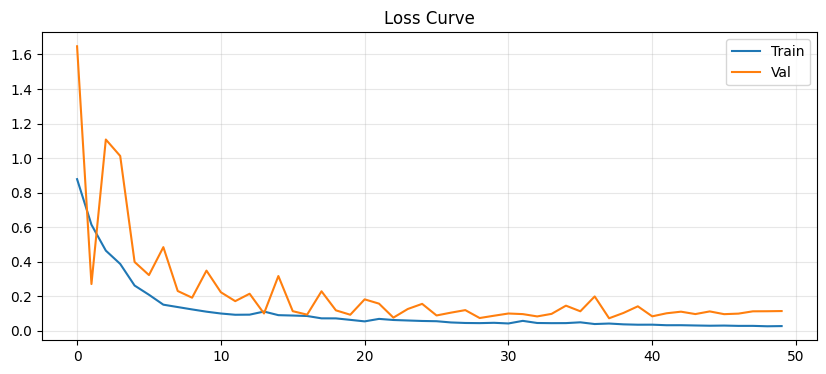

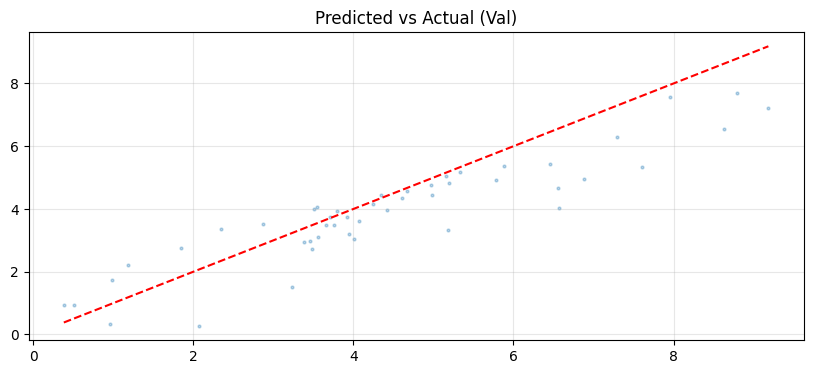

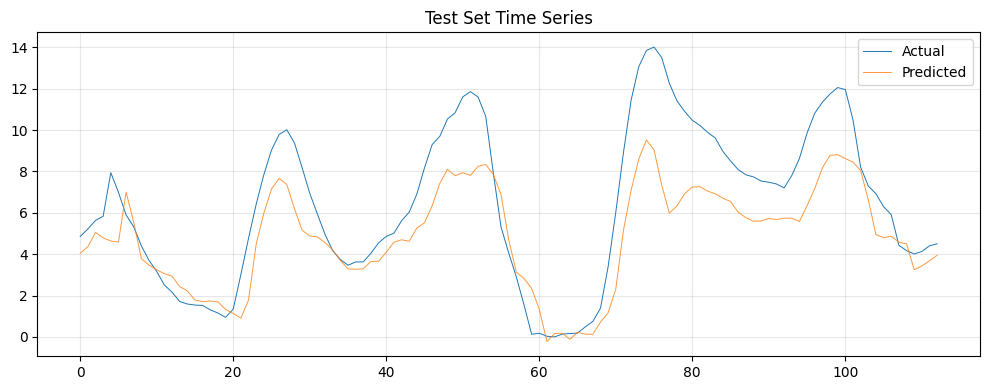

In [12]:
# ── 9. EVALUATE ───────────────────────────────────────────────────────────────
def predict(X_sc):
    model.eval()
    with torch.no_grad():
        return model(torch.from_numpy(X_sc)).numpy().flatten() * y_std + y_mean

y_test_pred = predict(X_te_sc)
y_val_pred  = predict(X_va_sc)

print(f"Test  RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"Val   RMSE : {np.sqrt(mean_squared_error(y_val,  y_val_pred)):.4f}")
print(f"Test  R²   : {r2_score(y_test, y_test_pred):.4f}")

# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_title('Loss Curve'); ax.legend(); ax.grid(True, alpha=0.3)

# Predicted vs Actual scatter
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(y_val, y_val_pred, alpha=0.3, s=4)
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
ax.set_title('Predicted vs Actual (Val)'); ax.grid(True, alpha=0.3)

# Time series
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test, linewidth=0.7, label='Actual')
ax.plot(y_test_pred, linewidth=0.7, label='Predicted', alpha=0.8)
ax.set_title('Test Set Time Series'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ── MODEL SUMMARY ─────────────────────────────────────────────────────────────
print("=" * 50)
print("MODEL SUMMARY")
print("=" * 50)

# Architecture
print(f"\nArchitecture   : {bp['arch'].upper()}")
print(f"Hidden units   : {bp['hidden']}")
print(f"Learning rate  : {bp['lr']:.6f}")
print(f"Dropout        : {bp['dropout']:.4f}")
if bp['arch'] == 'cnn_lstm':
    print(f"CNN channels   : {bp.get('channels', 32)}")

# Data config
print(f"\nLag            : {LAG}")
print(f"Horizon        : {HORIZON}")
print(f"Features       : {N_FEATURES}")
print(f"Train samples  : {len(X_train_w)}")
print(f"Test samples   : {len(X_test_w)}")
print(f"Val samples    : {len(X_val_w)}")

# Performance
print(f"\nTest  RMSE     : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f} °C")
print(f"Val   RMSE     : {np.sqrt(mean_squared_error(y_val,  y_val_pred)):.4f} °C")
print(f"Test  R²       : {r2_score(y_test, y_test_pred):.4f}")
print(f"Val   R²       : {r2_score(y_val,  y_val_pred):.4f}")

# Training
print(f"\nEpochs trained : {len(train_losses)}")
print(f"Best val MSE   : {study.best_value:.6f}")
print(f"\nFull model     :\n{model}")
print("=" * 50)

MODEL SUMMARY

Architecture   : CNN_LSTM
Hidden units   : 128
Learning rate  : 0.002916
Dropout        : 0.2694
CNN channels   : 16

Lag            : 20
Horizon        : 1
Features       : 1
Train samples  : 449
Test samples   : 113
Val samples    : 47

Test  RMSE     : 2.2704 °C
Val   RMSE     : 1.0346 °C
Test  R²       : 0.6262
Val   R²       : 0.7619

Epochs trained : 50
Best val MSE   : 0.076386

Full model     :
CNNLSTMModel(
  (cnn): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
  )
  (lstm): LSTM(16, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
